In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os
import requests
import PIL
import sklearn
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import cv2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
data_dir = r'/content/drive/MyDrive/Plant_Disease_Detection/train'

In [3]:
import numpy as np
import cv2
import os # Import the os module
img_height, img_width = 224,224

data= []
output= []
all_dirs = os.listdir(data_dir)
chunk_size = 19

for i in range(0, len(all_dirs), chunk_size):
    dir_chunk = all_dirs[i:i + chunk_size]
    print(f"Processing directories: {dir_chunk}")
    for ind, i in enumerate(dir_chunk):
        print(f"Processing directory: {i}")
        dir_path = os.path.join(data_dir, i)
        for ind2, j in enumerate(os.listdir(dir_path)):
            img_path = os.path.join(dir_path, j)
            img = cv2.imread(img_path)
            if img is not None:
                # Resize the image before appending
                img_resized = cv2.resize(img, (img_width, img_height))
                data.append(img_resized)
                output.append(i)
            else:
                print(f"Failed to load image: {img_path}")

Processing directories: ['10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28']
Processing directory: 10
Processing directory: 11
Processing directory: 12
Processing directory: 13
Processing directory: 14
Processing directory: 15
Processing directory: 16
Processing directory: 17
Processing directory: 18
Processing directory: 19
Processing directory: 20
Processing directory: 21
Processing directory: 22
Processing directory: 23
Processing directory: 24
Processing directory: 25
Processing directory: 26
Processing directory: 27
Processing directory: 28
Processing directories: ['29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '5', '6', '7', '8', '9', '0', '1', '2']
Processing directory: 29
Processing directory: 3
Processing directory: 30
Processing directory: 31
Processing directory: 32
Processing directory: 33
Processing directory: 34
Processing directory: 35
Processing directory: 36
Processing directory: 37
Processi

In [ ]:
img_height, img_width = 224,224
batch_size = 32

data_train = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

[[[134 177 140]
  [134 178 141]
  [136 182 144]
  ...
  [ 76 145 100]
  [ 74 143  98]
  [ 72 141  96]]

 [[138 180 143]
  [136 179 142]
  [135 179 142]
  ...
  [ 75 144  99]
  [ 73 142  97]
  [ 70 139  94]]

 [[139 180 143]
  [136 178 141]
  [133 177 140]
  ...
  [ 75 144  99]
  [ 71 140  95]
  [ 68 137  92]]

 ...

 [[109 177 142]
  [110 178 143]
  [111 178 143]
  ...
  [ 82 142 108]
  [ 85 144 110]
  [ 76 136 102]]

 [[119 188 152]
  [118 187 151]
  [115 185 149]
  ...
  [ 80 142 108]
  [ 81 143 109]
  [ 78 141 106]]

 [[130 200 164]
  [124 194 158]
  [116 186 150]
  ...
  [ 81 145 110]
  [ 84 148 113]
  [ 90 154 119]]]


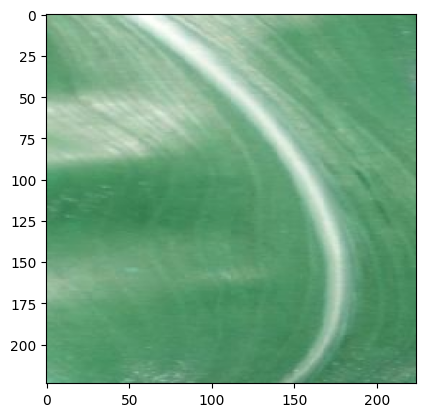

In [4]:
print(data[0])
plt.imshow(data[0])
plt.show()

In [5]:
print(output[0])

10


In [6]:
import random
temp = list(zip(data, output))
random.shuffle(temp)
res1, res2 = zip(*temp)
# res1 and res2 come out as tuples, and so must be converted to lists.
data, output = list(res1),list(res2)

In [7]:
print(data[0],output[0])

[[[160 145 153]
  [159 144 152]
  [158 143 151]
  ...
  [128 118 130]
  [129 119 131]
  [122 112 124]]

 [[161 146 154]
  [161 146 154]
  [161 146 154]
  ...
  [120 110 122]
  [125 115 127]
  [135 125 137]]

 [[153 138 146]
  [154 139 147]
  [155 140 148]
  ...
  [127 117 129]
  [133 123 135]
  [147 137 149]]

 ...

 [[174 166 173]
  [190 182 189]
  [191 183 190]
  ...
  [165 159 170]
  [163 156 168]
  [162 156 167]]

 [[185 177 184]
  [186 178 185]
  [176 168 175]
  ...
  [167 161 172]
  [165 159 170]
  [161 155 166]]

 [[201 193 200]
  [193 185 192]
  [197 189 196]
  ...
  [169 163 174]
  [167 161 172]
  [161 155 166]]] 19


In [11]:
classes={
    'Apple___Apple_scab': 0,
    'Apple___Black_rot': 1,
    'Apple___Cedar_apple_rust': 2,
    'Apple___healthy': 3,
    'Blueberry___healthy': 4,
    'Cherry_(including_sour)___healthy': 5,
    'Cherry_(including_sour)___Powdery_mildew': 6,
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
    'Corn_(maize)___Common_rust_': 8,
    'Corn_(maize)___healthy': 9,
    'Corn_(maize)___Northern_Leaf_Blight': 10,
    'Grape___Black_rot': 11,
    'Grape___Esca_(Black_Measles)': 12,
    'Grape___healthy': 13,
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 14,
    'Orange___Haunglongbing_(Citrus_greening)': 15,
    'Peach___Bacterial_spot': 16,
    'Peach___healthy': 17,
    'Pepper,_bell___Bacterial_spot': 18,
    'Pepper,_bell___healthy': 19,
    'Potato___Early_blight': 20,
    'Potato___healthy': 21,
    'Potato___Late_blight': 22,
    'Raspberry___healthy': 23,
    'Soybean___healthy': 24,
    'Squash___Powdery_mildew': 25,
    'Strawberry___healthy': 26,
    'Strawberry___Leaf_scorch': 27,
    'Tomato___Bacterial_spot': 28,
    'Tomato___Early_blight': 29,
    'Tomato___healthy': 30,
    'Tomato___Late_blight': 31,
    'Tomato___Leaf_Mold': 32,
    'Tomato___Septoria_leaf_spot': 33,
    'Tomato___Spider_mites Two-spotted_spider_mite': 34,
    'Tomato___Target_Spot': 35,
    'Tomato___Tomato_mosaic_virus': 36,
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 37
}
classes_reverse={
    0: 'Apple___Apple_scab',
    1: 'Apple___Black_rot',
    2: 'Apple___Cedar_apple_rust',
    3: 'Apple___healthy',
    4: 'Blueberry___healthy',
    5: 'Cherry_(including_sour)___healthy',
    6: 'Cherry_(including_sour)___Powdery_mildew',
    7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    8: 'Corn_(maize)___Common_rust_',
    9: 'Corn_(maize)___healthy',
    10: 'Corn_(maize)___Northern_Leaf_Blight',
    11: 'Grape___Black_rot',
    12: 'Grape___Esca_(Black_Measles)',
    13: 'Grape___healthy',
    14: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    15: 'Orange___Haunglongbing_(Citrus_greening)',
    16: 'Peach___Bacterial_spot',
    17: 'Peach___healthy',
    18: 'Pepper,_bell___Bacterial_spot',
    19: 'Pepper,_bell___healthy',
    20: 'Potato___Early_blight',
    21: 'Potato___healthy',
    22: 'Potato___Late_blight',
    23: 'Raspberry___healthy',
    24: 'Soybean___healthy',
    25: 'Squash___Powdery_mildew',
    26: 'Strawberry___healthy',
    27: 'Strawberry___Leaf_scorch',
    28: 'Tomato___Bacterial_spot',
    29: 'Tomato___Early_blight',
    30: 'Tomato___healthy',
    31: 'Tomato___Late_blight',
    32: 'Tomato___Leaf_Mold',
    33: 'Tomato___Septoria_leaf_spot',
    34: 'Tomato___Spider_mites Two-spotted_spider_mite',
    35: 'Tomato___Target_Spot',
    36: 'Tomato___Tomato_mosaic_virus',
    37: 'Tomato___Tomato_Yellow_Leaf_Curl_Virus'
}

In [ ]:
# Assuming 'output' is your list of numerical labels
# and 'classes_reverse' is your dictionary mapping numbers to class names

updated_output = []  # Create a new list to store the updated labels

for label in output:
    # Convert the label to an integer if it's a string
    label = int(label)

    # Get the class name from classes_reverse
    class_name = classes_reverse.get(label)

    # If the class name is found, append it to the updated_output list
    if class_name:
        updated_output.append(class_name)
    else:
        # Handle the case where the label is not found in classes_reverse
        print(f"Unknown label: {label}")
        # You might want to append a default value or handle this case differently

# Now updated_output contains the class names instead of numerical labels
output = updated_output  # Replace the original output with the updated one

In [9]:
print(output[0],output[1])

19 13


In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import InputLayer

resnet_model6 = Sequential()

pretrained_model = tf.keras.applications.ResNet50(include_top=False,
                                                  input_shape=(224, 224, 3),
                                                  pooling='avg',
                                                  weights='imagenet')

resnet_model6.add(InputLayer(input_shape=(224, 224, 3)))

resnet_model6.add(pretrained_model)

resnet_model6.add(Flatten())

resnet_model6.add(Dense(512, activation='relu'))
resnet_model6.add(BatchNormalization())

resnet_model6.add(Dense(38, activation='softmax'))

resnet_model6.compile(optimizer=Adam(learning_rate=0.001),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

resnet_model6.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,658,342 (94.06 MB)

 Trainable params: 24,604,198 (93.86 MB)

 Non-trainable params: 54,144 (211.50 KB)

In [30]:
len(data)

8751

In [31]:
len(output)

8751

In [13]:
output_int = np.array([int(label) for label in output])

In [14]:
data=np.asarray(data)
output=np.asarray(output_int)

In [15]:
# Sanity checks
print("Data shape:", data.shape, "dtype:", data.dtype)
print("Output shape:", output.shape, "dtype:", output.dtype, "classes:", np.unique(output))

Data shape: (8751, 224, 224, 3) dtype: uint8
Output shape: (8751,) dtype: int64 classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]


In [32]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stopping = EarlyStopping(
    monitor='loss',      # Monitor training loss instead of validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,  # Restores model weights from the epoch with the best value of the monitored quantity
    min_delta=0.001      # Minimum change in the monitored quantity to qualify as an improvement
)

# Train the model with early stopping
epochs = 30
batch_size = 32
history = resnet_model6.fit(
    x=data,
    y=output,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]  # Add the early stopping callback here
)

Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 164s 381ms/step - accuracy: 0.6875 - loss: 1.2014
Epoch 2/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 302ms/step - accuracy: 0.9158 - loss: 0.2563
Epoch 3/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 299ms/step - accuracy: 0.9585 - loss: 0.1417
Epoch 4/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - accuracy: 0.9550 - loss: 0.1416
Epoch 5/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - accuracy: 0.9685 - loss: 0.1018
Epoch 6/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - accuracy: 0.9713 - loss: 0.0835
Epoch 7/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - accuracy: 0.9765 - loss: 0.0805
Epoch 8/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 296ms/step - accuracy: 0.9748 - loss: 0.0789
Epoch 9/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - accuracy: 0.9768 - loss: 0.0696
Epoch 10/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - accuracy: 0.9858 - loss: 0.0443
Epoch 11/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 296ms/step - accuracy: 0.9892 - loss: 0.0425
Epoch 12/30
274/27

In [32]:
import cv2
image=cv2.imread(r"D:\Plant Disease Detection\PlantVillage-Dataset\data_distribution_for_SVM\test\32\0a3fabdb-d6e0-40f2-9efe-bafe1aa5732e.JPG")
image_resized= cv2.resize(image,(224,224))
pred=np.argmax(resnet_model2.predict(np.asarray([image_resized])))
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
32


In [30]:
output_class=list(classes.keys())[(pred)]
print("The predicted class is", output_class)

The predicted class is Apple___Cedar_apple_rust


In [6]:
def create_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.layers import InputLayer

    resnet_model = Sequential()

    pretrained_model = tf.keras.applications.ResNet50(include_top=False,
                                                    input_shape=(224, 224, 3),
                                                    pooling='avg',
                                                    weights='imagenet')

    resnet_model.add(InputLayer(input_shape=(224, 224, 3)))

    resnet_model.add(pretrained_model)

    resnet_model.add(Flatten())

    resnet_model.add(Dense(512, activation='relu'))
    resnet_model.add(BatchNormalization())

    resnet_model.add(Dense(38, activation='softmax'))

    resnet_model.compile(optimizer=Adam(learning_rate=0.001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

    return resnet_model

In [7]:
resnet_model2 = create_model()

# Load the weights
resnet_model2.load_weights(r"D:\Plant Disease Detection\model\Plant_Disease_Detection_ResNet50_model6.weights.h5")

# Optionally, print the model summary
resnet_model2.summary()

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 438 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,658,342 (94.06 MB)

 Trainable params: 24,604,198 (93.86 MB)

 Non-trainable params: 54,144 (211.50 KB)

In [ ]:
output_class=list(classes.keys())[(pred)]
print("The predicted class is", output_class)

The predicted class is Tomato___Leaf_Mold


In [49]:
resnet_model6.save_weights("Plant_Disease_Detection_ResNet50_model6.weights.h5")

In [20]:
data_dir_test= '/content/drive/MyDrive/Plant_Disease_Detection/test'

In [21]:
import numpy as np
import cv2
img_height, img_width = 224, 224

data_test = []
output_test = []
for ind, i in enumerate(os.listdir(data_dir_test)):
    print(f"Processing directory: {i}")
    dir_path = os.path.join(data_dir_test, i)
    for ind2, j in enumerate(os.listdir(dir_path)):
        img_path = os.path.join(dir_path, j)
        img = cv2.imread(img_path)
        if img is not None:
            # Resize the image before appending
            img_resized = cv2.resize(img, (img_width, img_height))
            data_test.append(img_resized)
            output_test.append(i)
        else:
            print(f"Failed to load image: {img_path}")

# Convert the list of images to a NumPy array
data_test2 = np.array(data_test)


Processing directory: 17
Processing directory: 22
Processing directory: 0
Processing directory: 1
Processing directory: 2
Processing directory: 3
Processing directory: 4
Processing directory: 5
Processing directory: 6
Processing directory: 7
Processing directory: 8
Processing directory: 9
Processing directory: 10
Processing directory: 11
Processing directory: 12
Processing directory: 13
Processing directory: 14
Processing directory: 15
Processing directory: 16
Processing directory: 18
Processing directory: 19
Processing directory: 20
Processing directory: 21
Processing directory: 23
Processing directory: 24
Processing directory: 25
Processing directory: 26
Processing directory: 27
Processing directory: 28
Processing directory: 29
Processing directory: 30
Processing directory: 31
Processing directory: 32
Processing directory: 33
Processing directory: 34
Processing directory: 35
Processing directory: 36
Processing directory: 37
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step


In [35]:
# Now use the resized data for prediction
predictions = resnet_model6.predict(data_test2)

70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step


In [36]:
classes_test={
    'Apple___Apple_scab': 0,
    'Apple___Black_rot': 1,
    'Apple___Cedar_apple_rust': 2,
    'Apple___healthy': 3,
    'Blueberry___healthy': 4,
    'Cherry_(including_sour)___healthy': 5,
    'Cherry_(including_sour)___Powdery_mildew': 6,
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
    'Corn_(maize)___Common_rust_': 8,
    'Corn_(maize)___healthy': 9,
    'Corn_(maize)___Northern_Leaf_Blight': 10,
    'Grape___Black_rot': 11,
    'Grape___Esca_(Black_Measles)': 12,
    'Grape___healthy': 13,
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 14,
    'Orange___Haunglongbing_(Citrus_greening)': 15,
    'Peach___Bacterial_spot': 16,
    'Peach___healthy': 17,
    'Pepper,_bell___Bacterial_spot': 18,
    'Pepper,_bell___healthy': 19,
    'Potato___Early_blight': 20,
    'Potato___healthy': 21,
    'Potato___Late_blight': 22,
    'Raspberry___healthy': 23,
    'Soybean___healthy': 24,
    'Squash___Powdery_mildew': 25,
    'Strawberry___healthy': 26,
    'Strawberry___Leaf_scorch': 27,
    'Tomato___Bacterial_spot': 28,
    'Tomato___Early_blight': 29,
    'Tomato___healthy': 30,
    'Tomato___Late_blight': 31,
    'Tomato___Leaf_Mold': 32,
    'Tomato___Septoria_leaf_spot': 33,
    'Tomato___Spider_mites Two-spotted_spider_mite': 34,
    'Tomato___Target_Spot': 35,
    'Tomato___Tomato_mosaic_virus': 36,
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 37
}
classes_reverse_test={
    0: 'Apple___Apple_scab',
    1: 'Apple___Black_rot',
    2: 'Apple___Cedar_apple_rust',
    3: 'Apple___healthy',
    4: 'Blueberry___healthy',
    5: 'Cherry_(including_sour)___healthy',
    6: 'Cherry_(including_sour)___Powdery_mildew',
    7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    8: 'Corn_(maize)___Common_rust_',
    9: 'Corn_(maize)___healthy',
    10: 'Corn_(maize)___Northern_Leaf_Blight',
    11: 'Grape___Black_rot',
    12: 'Grape___Esca_(Black_Measles)',
    13: 'Grape___healthy',
    14: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    15: 'Orange___Haunglongbing_(Citrus_greening)',
    16: 'Peach___Bacterial_spot',
    17: 'Peach___healthy',
    18: 'Pepper,_bell___Bacterial_spot',
    19: 'Pepper,_bell___healthy',
    20: 'Potato___Early_blight',
    21: 'Potato___healthy',
    22: 'Potato___Late_blight',
    23: 'Raspberry___healthy',
    24: 'Soybean___healthy',
    25: 'Squash___Powdery_mildew',
    26: 'Strawberry___healthy',
    27: 'Strawberry___Leaf_scorch',
    28: 'Tomato___Bacterial_spot',
    29: 'Tomato___Early_blight',
    30: 'Tomato___healthy',
    31: 'Tomato___Late_blight',
    32: 'Tomato___Leaf_Mold',
    33: 'Tomato___Septoria_leaf_spot',
    34: 'Tomato___Spider_mites Two-spotted_spider_mite',
    35: 'Tomato___Target_Spot',
    36: 'Tomato___Tomato_mosaic_virus',
    37: 'Tomato___Tomato_Yellow_Leaf_Curl_Virus'
}

In [37]:
max_indices = [np.argmax(pred).item() for pred in predictions]

output_test_int = np.array([int(label) for label in output_test])

In [38]:
print(output_test_int)

[17 17 17 ... 37 37 37]


In [39]:
print(predictions[0])

[6.3887166e-11 2.5449787e-13 8.7787113e-12 4.7096599e-10 1.6126431e-10
 2.1373009e-07 1.7527920e-11 9.2986220e-13 1.1871668e-10 4.7431295e-11
 4.0470405e-09 6.5665793e-12 1.4759756e-12 3.0567805e-11 4.7344767e-12
 2.8344234e-08 2.9207647e-05 9.9996483e-01 1.7416735e-12 5.7456418e-06
 8.8623636e-11 2.3681588e-12 1.8338603e-12 1.6621877e-10 9.4769004e-10
 5.9186635e-13 1.1272970e-11 2.4980630e-14 1.3565753e-11 1.3697823e-09
 3.3965172e-08 1.1025156e-11 1.3492486e-12 1.4576779e-09 2.0910142e-11
 4.3269364e-12 6.2268501e-10 9.3721156e-11]


In [ ]:
max_indices = [np.argmax(pred).item() for pred in predictions]
print(max_indices)

[34, 34, 34, 34, 34, 6, 34, 6, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 6, 34, 23, 6, 6, 34, 34, 34, 34, 34, 6, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 6, 6, 34, 34, 34, 34, 34, 34, 34, 34, 6, 34, 34, 34, 34, 34, 6, 34, 34, 6, 34, 34, 34, 23, 6, 34, 34, 34, 34, 6, 34, 34, 34, 34, 34, 34, 34, 6, 34, 34, 34, 34, 34, 34, 6, 34, 34, 34, 34, 34, 6, 34, 6, 34, 34, 34, 34, 34, 6, 34, 34, 34, 34, 6, 34, 23, 34, 34, 6, 34, 23, 34, 23, 34, 6, 34, 34, 34, 34, 34, 34, 34, 23, 34, 34, 34, 34, 34, 34, 34, 34, 6, 34, 34, 34, 34, 34, 34, 23, 34, 34, 34, 23, 23, 1, 30, 23, 23, 1, 1, 30, 33, 25, 26, 23, 25, 23, 25, 23, 24, 24, 1, 23, 26, 24, 30, 26, 26, 25, 29, 24, 33, 5, 33, 33, 29, 29, 29, 29, 29, 29, 33, 18, 29, 33, 22, 33, 33, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 18, 29, 29, 29, 29, 29, 29, 29, 18, 33, 33, 29, 33, 33, 29, 3, 29, 18, 18, 29, 8, 29, 29, 8, 29, 29, 33, 18, 33, 29, 29, 29, 29, 29, 29, 29, 29, 33, 29, 29, 29, 29, 29, 29, 29, 24, 18, 33, 7, 8, 29, 29, 18, 29, 29, 29, 29, 29, 23, 29, 29,

In [40]:
from sklearn.metrics import classification_report
import numpy as np

# Generate the classification report
print(classification_report(output_test_int, max_indices))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92        49
           1       1.00      0.91      0.95        34
           2       0.90      1.00      0.95         9
           3       0.98      0.97      0.98       125
           4       0.99      0.97      0.98        78
           5       0.97      1.00      0.98       157
           6       0.98      0.98      0.98       141
           7       0.94      0.79      0.86        43
           8       1.00      1.00      1.00        72
           9       0.88      0.92      0.90        61
          10       0.98      1.00      0.99        50
          11       1.00      1.00      1.00        89
          12       1.00      1.00      1.00        61
          13       0.98      1.00      0.99        59
          14       1.00      1.00      1.00        18
          15       0.92      0.99      0.96       145
          16       0.97      1.00      0.99        39
          17       1.00    